# An Iterative Workflow means:

The same step (or group of steps) is repeated until a condition is satisfied.



In [ ]:
# Real-Life Example: Solving a Coding Problem
Write Code
     │
     ▼
Run Tests
     │
     ▼
Tests Passed?
     │
 ┌───┴────┐
 ▼        ▼
No       Yes
 │         │
 ▼         ▼
Fix Code  Finish
 │
 └───────────────┐
                 │
                 ▼
            Run Tests Again

You keep repeating the process until all tests pass.

# In LangGraph

An iterative workflow is implemented by creating a loop in the graph.

Conceptually:

def evaluate(state):

    if state["quality"] >= 0.9:

        return "END"
        
    else:
    
        return "retrieve_again"

If the quality is not good enough, the graph loops back to another node instead of ending.

In [ ]:
# Why Use Iterative Workflows?

Suppose you're building a customer support AI.

Without iteration:

Question
   │
   ▼
Generate Answer
   │
   ▼
Return

If the answer is wrong, the workflow ends.

With iteration:

Question
    │
    ▼
Generate Answer
    │
    ▼
Check Confidence
    │
 ┌──┴────┐
 ▼       ▼
Low     High
 │        │
 ▼        ▼
Search  Return
Again
 │
 └────────► Generate Again

The AI gets another chance to improve the answer.

# Advantages
✅ Improves answer quality
✅ Can self-correct mistakes
✅ Reduces hallucinations
✅ Useful for complex reasoning tasks
✅ Supports retry mechanisms


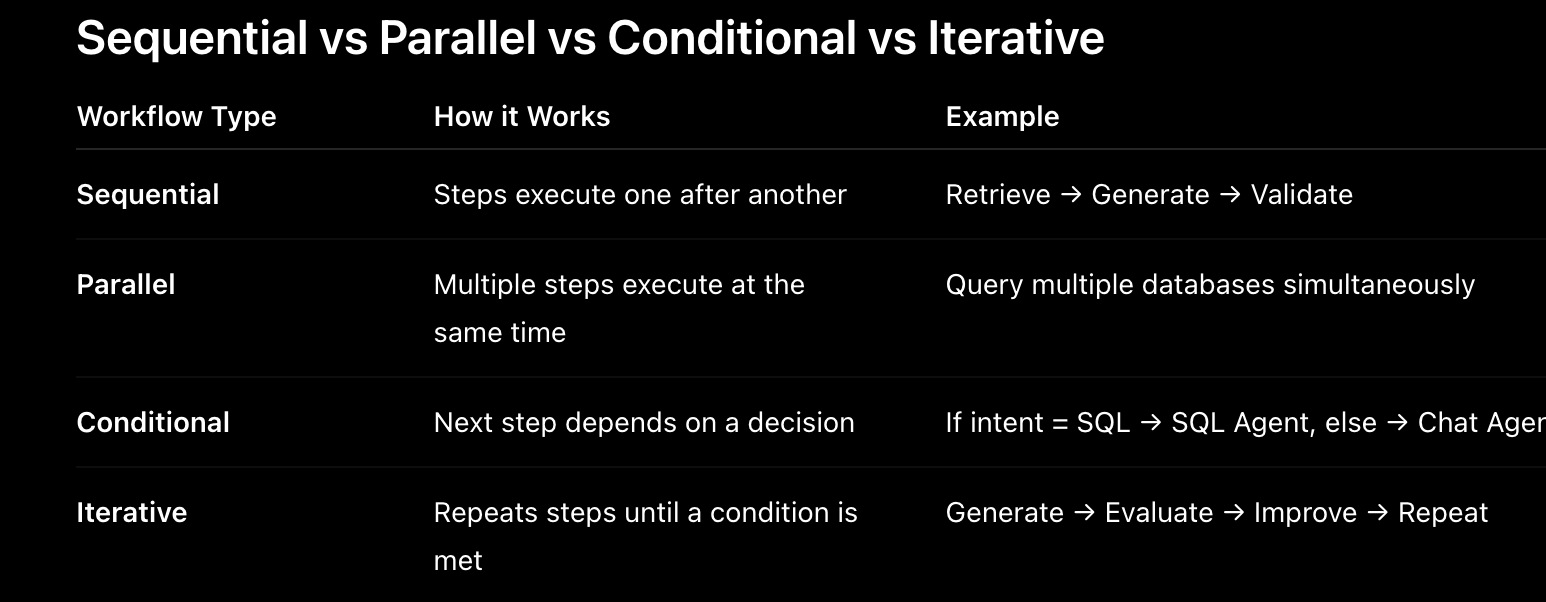

# An iterative workflow is a workflow where one or more steps are repeatedly executed until a stopping condition is met. The system evaluates the output after each iteration and, if it does not satisfy the required quality or success criteria, loops back to retry or improve the result. This is commonly used for self-correction, answer refinement, debugging, and retrieval improvement in AI systems.

# X_post_generator Code

In [8]:
# Install langchain-openai
!pip install langchain-openai

from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
import operator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.4/120.4 kB 7.6 MB/s eta 0:00:00


In [21]:
import os
os.environ["OPENAI_API_KEY"] = "YOUR_API_KEY" # Replace YOUR_API_KEY with your actual OpenAI API Key
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [14]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [15]:

structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [16]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [17]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [18]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


In [19]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}


In [25]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

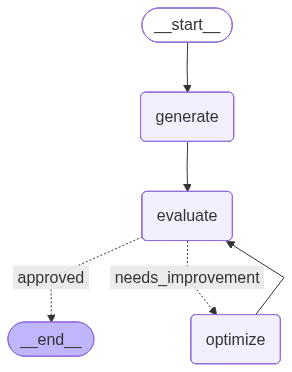

In [26]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [29]:
initial_state = {
    "topic": "srhberhb",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)


AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: YOUR_API_KEY. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}

In [28]:
result

NameError: name 'result' is not defined

In [24]:
for tweet in result['tweet_history']:
    print(tweet)

NameError: name 'result' is not defined